In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("WHO COVID-19 cases.csv")

In [3]:
df.head()

,Date_reported,Country_code,Country,Continent,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,1/5/2020,AF,Afghanistan,Asia,EMRO,0,0,0,0
1,1/12/2020,AF,Afghanistan,Asia,EMRO,0,0,0,0
2,1/19/2020,AF,Afghanistan,Asia,EMRO,0,0,0,0
3,1/26/2020,AF,Afghanistan,Asia,EMRO,0,0,0,0
4,2/2/2020,AF,Afghanistan,Asia,EMRO,0,0,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58560 entries, 0 to 58559
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Date_reported      58560 non-null  str  
 1   Country_code       58316 non-null  str  
 2   Country            58560 non-null  str  
 3   Continent          58560 non-null  str  
 4   WHO_region         54168 non-null  str  
 5   New_cases          58560 non-null  int64
 6   Cumulative_cases   58560 non-null  int64
 7   New_deaths         58560 non-null  int64
 8   Cumulative_deaths  58560 non-null  int64
dtypes: int64(4), str(5)
memory usage: 4.0 MB


In [5]:
df.isnull().sum()

Date_reported           0
Country_code          244
Country                 0
Continent               0
WHO_region           4392
New_cases               0
Cumulative_cases        0
New_deaths              0
Cumulative_deaths       0
dtype: int64

In [6]:
df["Date_reported"] = pd.to_datetime(df["Date_reported"])

In [7]:
plt.figure(figsize=(14,6))
plt.plot(daily_cases.index, daily_cases.values)
plt.title("Global Daily COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

NameError: name 'daily_cases' is not defined

<Figure size 1400x600 with 0 Axes>

In [8]:
print(df.columns)


Index(['Date_reported', 'Country_code', 'Country', 'Continent', 'WHO_region',
       'New_cases', 'Cumulative_cases', 'New_deaths', 'Cumulative_deaths'],
      dtype='str')


In [9]:
df["Date_reported"] = pd.to_datetime(df["Date_reported"])

In [10]:
daily_cases = df.groupby("Date_reported")["New_cases"].sum()

daily_cases.head()

Date_reported
2020-01-05        2
2020-01-12       45
2020-01-19       90
2020-01-26     1895
2020-02-02    12538
Name: New_cases, dtype: int64

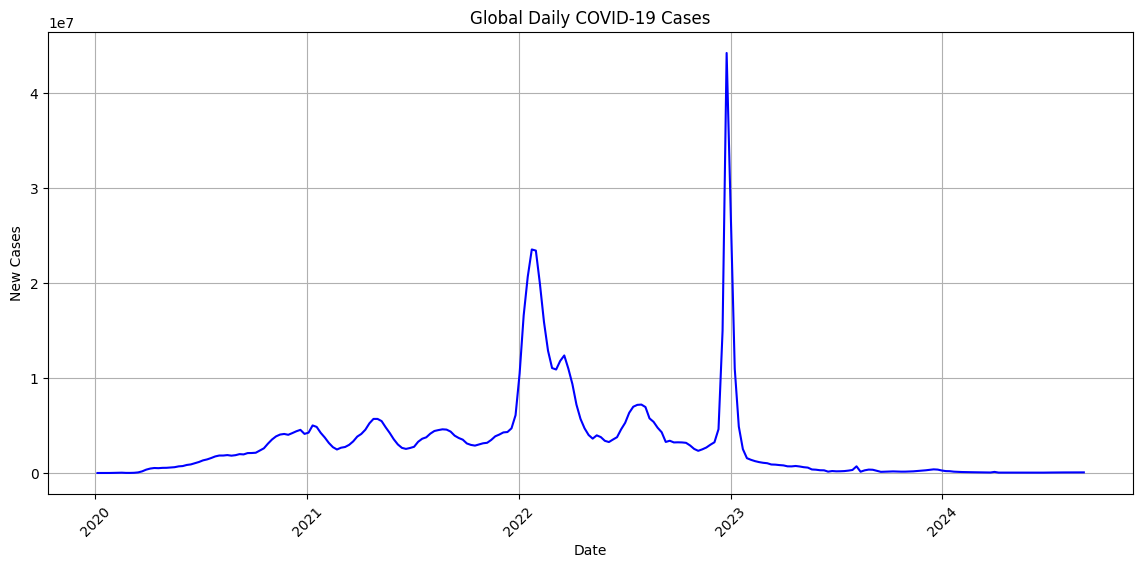

In [11]:
plt.figure(figsize=(14,6))

plt.plot(daily_cases.index, daily_cases.values, color="blue")

plt.title("Global Daily COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

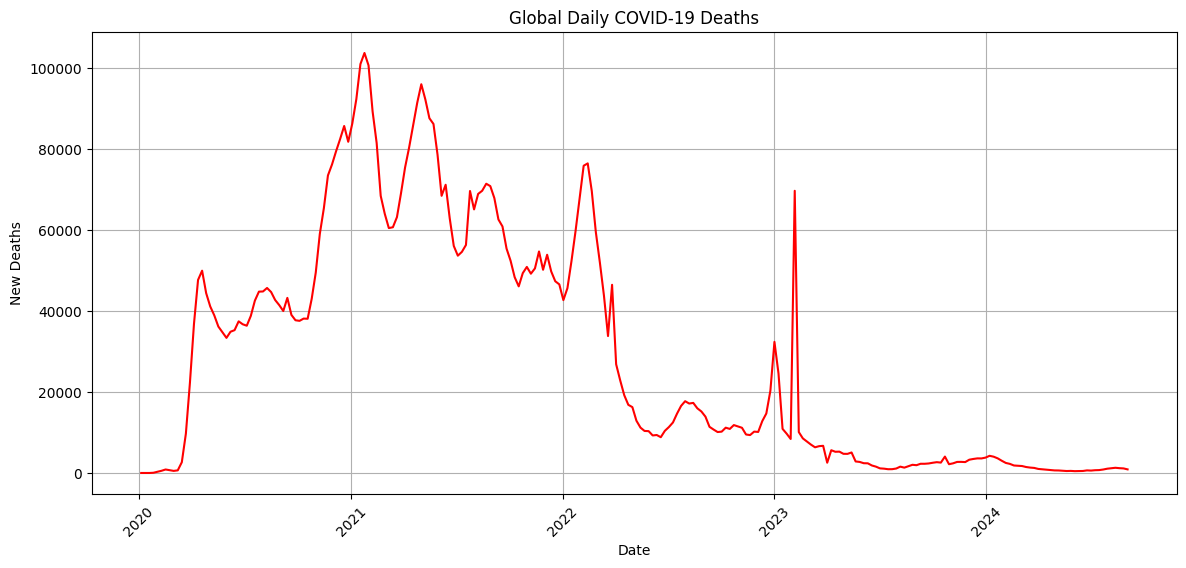

In [12]:
daily_deaths = df.groupby("Date_reported")["New_deaths"].sum()

plt.figure(figsize=(14,6))
plt.plot(daily_deaths.index, daily_deaths.values, color='red')

plt.title("Global Daily COVID-19 Deaths")
plt.xlabel("Date")
plt.ylabel("New Deaths")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

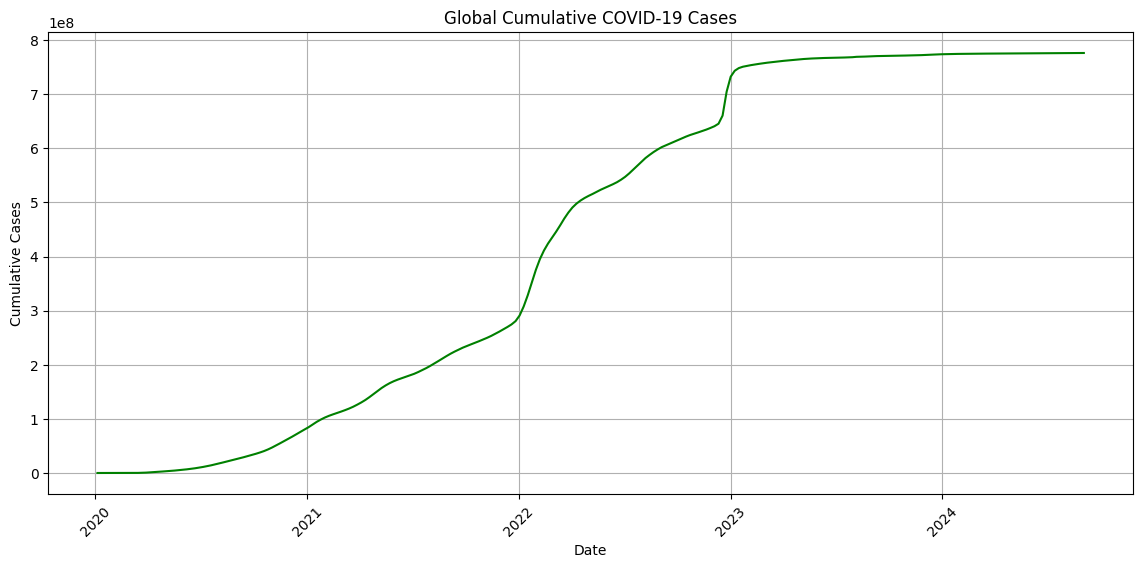

In [13]:
cumulative_cases = df.groupby("Date_reported")["Cumulative_cases"].sum()

plt.figure(figsize=(14,6))
plt.plot(cumulative_cases.index, cumulative_cases.values, color='green')

plt.title("Global Cumulative COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Cumulative Cases")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

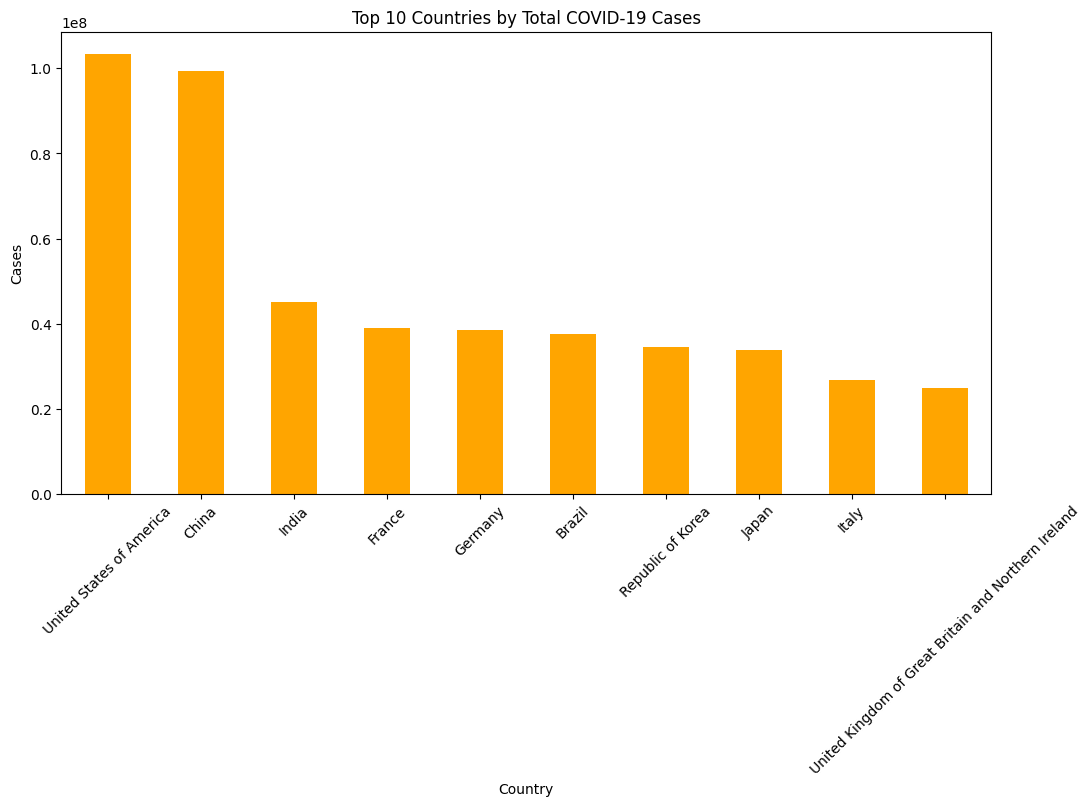

In [14]:
top10 = df.groupby("Country")["Cumulative_cases"].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top10.plot(kind='bar', color='orange')

plt.title("Top 10 Countries by Total COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Cases")

plt.xticks(rotation=45)

plt.show()

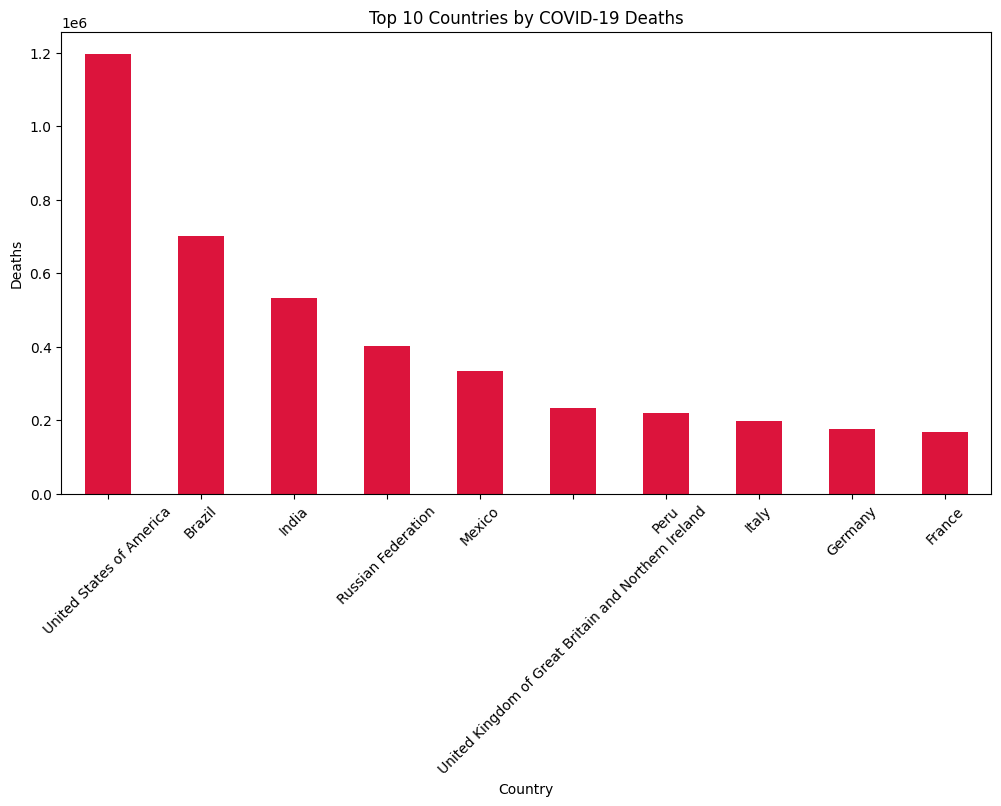

In [15]:
top10_deaths = df.groupby("Country")["Cumulative_deaths"].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top10_deaths.plot(kind='bar', color='crimson')

plt.title("Top 10 Countries by COVID-19 Deaths")
plt.xlabel("Country")
plt.ylabel("Deaths")

plt.xticks(rotation=45)

plt.show()